In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

sys.path.insert(0, str(Path.cwd().parent))  # points to src/
from shared_modeling import (
    build_combined_feature_frame,
    create_pipeline,
    get_feature_names_from_pipeline,
    load_or_create_master_split_ids,
    plot_confusion_matrix_for_model,
    plot_model_feature_importance,
    plot_permutation_importance_for_model,
    plot_roc_curve_for_model,
    plot_shap_summary_for_model,
    run_interpretability_suite,
    run_model_experiment,
)
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, auc, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline  # Use imblearn's Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import numpy as np
import shap
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK


/Users/mkorpusi/Documents/GitHub/numom2b/nuMoM2b/src/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/mkorpusi/Documents/GitHub/numom2b/nuMoM2b/src/.venv/lib/python3.13/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
combined_inputs = build_combined_feature_frame(
    data_dir=Path('../../Data'),
    outcome_path='Modified/Outcome.csv',
    outcome_column='MH_outcome'
)
feature_lists = combined_inputs['feature_lists']
numeric_features = feature_lists['numeric_features']
categorical_features = feature_lists['categorical_features']
ordinal_features = feature_lists['ordinal_features']
binary_features = feature_lists['binary_features']
feature_columns = feature_lists['feature_columns']
combined_df = combined_inputs['combined_df']
outcome_df = combined_inputs['outcome_df']

split_path = 'master_split_ids.csv'
train_ids, test_ids = load_or_create_master_split_ids(outcome_df, split_path)

X = combined_df[feature_columns]
y = combined_df['MH_outcome']
train_df = combined_df[combined_df['PublicID'].isin(train_ids)].copy()
test_df = combined_df[combined_df['PublicID'].isin(test_ids)].copy()
X_train = train_df.drop(['MH_outcome', 'PublicID'], axis=1)
X_test = test_df.drop(['MH_outcome', 'PublicID'], axis=1)
y_train = train_df['MH_outcome']
y_test = test_df['MH_outcome']
combined_df

,PublicID,oDM,ChronHTN,acog_PEgHTN,ResilienceTotalScore,ResilienceLevel,stress_average,FrequencyOfHassles,FrequencyOfUplifts,IntensityOfHassles,...,V2AJ01a2,rest_dur_avg_all_Mod,rest_sleeptime_avg_all_Mod,rest_sleeptime_avg_wkday_Mod,sleep_dur_avg_all_Mod,sleep_sleeptime_avg_all_Mod,sleep_Frag_avg_all_Mod,sleep_WASO_avg_all_Mod,sleep_SE_avg_all_Mod,MH_outcome
0,00004O,3.0,2.0,7.0,102.0,1.0,1.846154,10.0,10.0,2.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,00007I,3.0,2.0,7.0,106.0,1.0,1.538462,10.0,10.0,2.0,...,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,00008G,3.0,2.0,7.0,107.0,1.0,2.076923,10.0,10.0,2.2,...,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,00015J,3.0,2.0,7.0,120.0,1.0,1.692308,10.0,10.0,1.4,...,45.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,00016H,3.0,2.0,7.0,97.0,2.0,2.000000,10.0,10.0,1.5,...,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7736,17349I,3.0,2.0,7.0,98.0,2.0,1.461538,10.0,10.0,1.7,...,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
7737,17350A,3.0,2.0,3.0,119.0,1.0,1.384615,NaN,NaN,NaN,...,120.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
7738,17351V,3.0,2.0,7.0,104.0,1.0,1.384615,NaN,NaN,NaN,...,NaN,655.000000,574.333313,536.125000,645.833313,569.583313,24.150002,76.25000,86.904999,0
7739,17352T,3.0,2.0,7.0,100.0,2.0,1.538462,10.0,10.0,1.4,...,30.0,436.928558,387.714294,367.799988,428.857147,386.285706,18.521427,42.57143,88.264290,1


In [3]:
# LR block using all domain features, with mother demographics split into numeric and categorical inputs.
lr_model, lr_pred, lr_metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'lr',
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    ordinal_features=ordinal_features,
    binary_features=binary_features,
    impute=True
)

Final dataset sizes for LR (impute=True): train=6192, test=1549
Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for 

Best parameters found: {'classifier__C': 100, 'classifier__l1_ratio': 0.0}
Best CV Score (f1): 0.6832
Model Coefficients:
num__ResilienceTotalScore: -0.23771093545605382
num__stress_average: 0.5410836987915366
num__FrequencyOfHassles: -0.0358178459730017
num__FrequencyOfUplifts: 0.12993734535515697
num__IntensityOfHassles: -0.08014989989645986
num__IntensityOfUplifts: 0.2502499863923285
num__HassleUpliftFrequencyRatio: 0.020279109565900948
num__HassleUpliftIntensityRatio: 0.36437179449767154
num__StressTotalScore: 0.7649492449766889
num__V2AF13: -0.031545599986686226
num__V2AF15: 0.032813158740301676
num__DT_FOLAC: 0.021262962538232313
num__DT_CALC: 0.11485554174530907
num__VITD_MCG: -0.18711531067276335
num__TOTAL_CHOLINE: 0.23351248885397494
num__DT_SODI: 0.15268029553375334
num__PRENATALYEARS: -0.06750643125275238
num__AHEI2010: 0.7679387273879541
num__AHEI_ALCDRKS: -0.23988933094993364
num__AHEI_SODIUM: -0.2001277786971752
num__AHEI_PUFAPCT: 0.01942620072152987
num__AHEI_DHAEPA: -0

In [4]:
# RF block using all domain features, with mother demographics split into numeric and categorical inputs.
rf_model, rf_pred, rf_metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'rf',
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    ordinal_features=ordinal_features,
    binary_features=binary_features,
    impute=True
)

Final dataset sizes for RF (impute=True): train=6192, test=1549
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters found: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 3, 'classifier__n_estimators': 500}
Best CV Score (f1): 0.6694
Feature Importances:
num__ResilienceTotalScore: 0.054641368073627024
num__stress_average: 0.07029860630537976
num__FrequencyOfHassles: 1.7586009669343634e-06
num__FrequencyOfUplifts: 8.380503297479618e-06
num__IntensityOfHassles: 0.03568264405445343
num__IntensityOfUplifts: 0.014989311895113187
num__HassleUpliftFrequencyRatio: 0.0
num__HassleUpliftIntensityRatio: 0.03458579567902805
num__StressTotalScore: 0.09696053165135998
num__V2AF13: 0.013287279791338749
num__V2AF15: 0.013190315869871693
num__DT_FOLAC: 0.013045046632622695
num__DT_CALC: 0.011042117414473461
num__VITD_MCG: 0.012211308645127253
num__TOTAL_CHOLINE: 0.01055017568943851
num__DT_SODI: 0.010558221460599761
num__PRENAT

In [5]:
# XGBoost block using all domain features, with mother demographics split into numeric and categorical inputs.
xgb_model, xgb_pred, xgb_metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'xgb',
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    ordinal_features=ordinal_features,
    binary_features=binary_features,
    impute=True
)

Final dataset sizes for XGB (impute=True): train=6192, test=1549
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best parameters found: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 6, 'classifier__n_estimators': 60, 'classifier__subsample': 0.7}
Best CV Score (f1): 0.6741
Feature Importances:
num__ResilienceTotalScore: 0.014141670428216457
num__stress_average: 0.0364239439368248
num__FrequencyOfHassles: 0.0
num__FrequencyOfUplifts: 0.0
num__IntensityOfHassles: 0.014195232652127743
num__IntensityOfUplifts: 0.0063110473565757275
num__HassleUpliftFrequencyRatio: 0.0
num__HassleUpliftIntensityRatio: 0.010054879821836948
num__StressTotalScore: 0.05999699980020523
num__V2AF13: 0.006463616155087948
num__V2AF15: 0.007763211149722338
num__DT_FOLAC: 0.006895543076097965
num__DT_CALC: 0.00664473045617342
num__VITD_MCG: 0.006825991440564394
num__TOTAL_CHOLINE: 0.007432984653860331
num__DT_SODI: 0.008184045553207397
num__PRENATALY

In [6]:
# SVM block using all domain features, with mother demographics split into numeric and categorical inputs.
svm_model, svm_pred, svm_metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'svm',
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    ordinal_features=ordinal_features,
    binary_features=binary_features,
    impute=True
)

Final dataset sizes for SVM (impute=True): train=6192, test=1549
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters found: {'classifier__estimator__C': 0.1, 'classifier__estimator__kernel': 'linear'}
Best CV Score (f1): 0.6799
Skipping feature-level SVM output to keep notebook output compact.
Evaluation Metrics for SVM with shared preprocessing and adaptive CV scoring:
Accuracy: 0.7205
Precision (positive class): 0.6522
Recall (positive class): 0.6698
F1 (positive class): 0.6609
Macro Precision: 0.7108
Macro Recall: 0.7125
Macro F1: 0.7116
ROC AUC: 0.7871


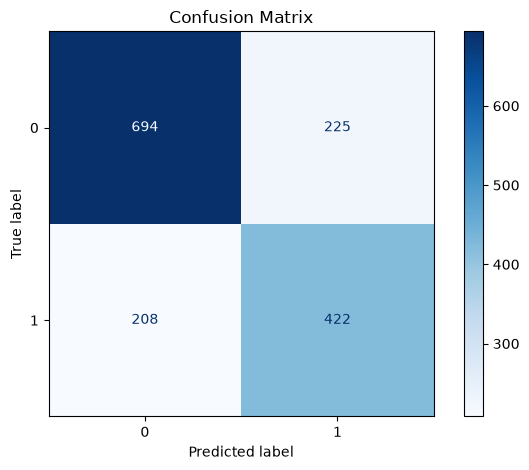

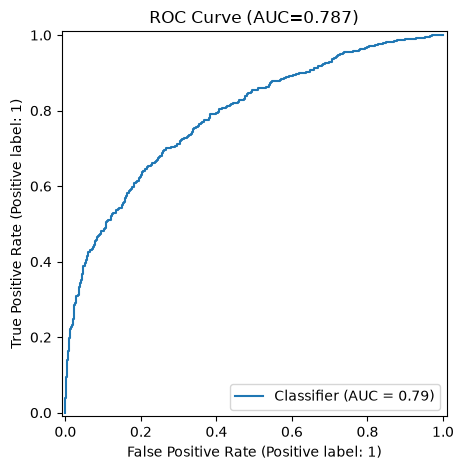

Feature importance skipped: model does not expose coefficients or feature_importances_.


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for 

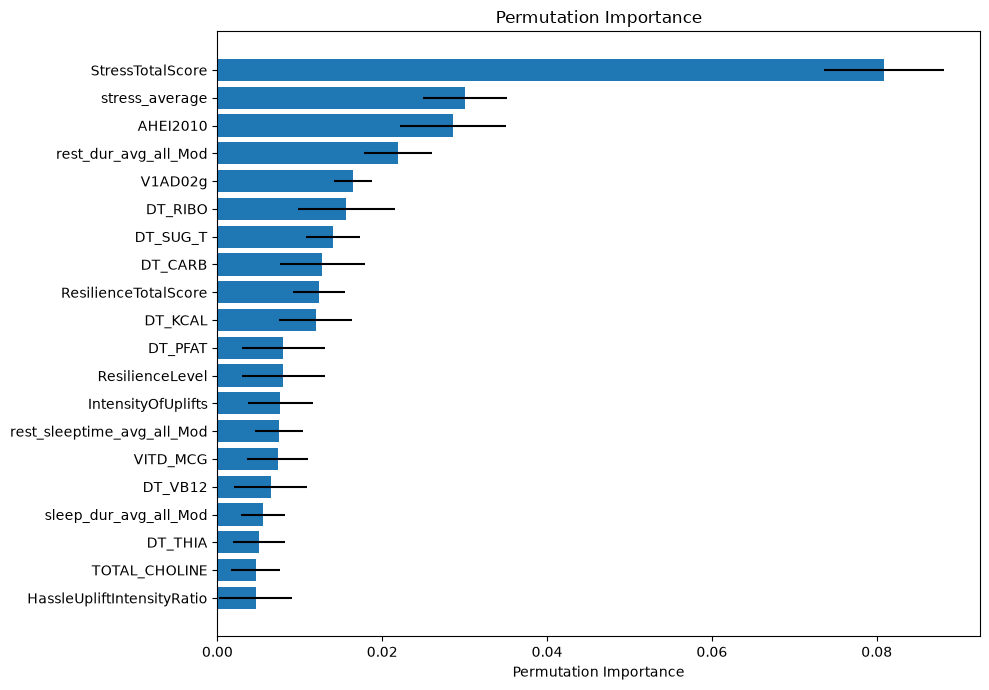

Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


SHAP skipped: The passed model is not callable and cannot be analyzed directly with the given masker! Model: CalibratedClassifierCV(ensemble=False, estimator=SVC(C=0.1, kernel='linear'))


In [8]:
# Interpretability for the SVM combined model.
# Swap svm_model for lr_model, rf_model, or xgb_model if you want a different view.
run_interpretability_suite(svm_model, X_train, X_test, y_test, labels=[0, 1], top_n=20)